<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/task_10_ibynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9223 - loss: 0.2675 - val_accuracy: 0.9606 - val_loss: 0.1331
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9666 - loss: 0.1101 - val_accuracy: 0.9688 - val_loss: 0.1038
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9760 - loss: 0.0772 - val_accuracy: 0.9711 - val_loss: 0.0905
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9818 - loss: 0.0583 - val_accuracy: 0.9728 - val_loss: 0.0937
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9852 - loss: 0.0467 - val_accuracy: 0.9732 - val_loss: 0.0952
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9890 - loss: 0.0343 - val_accuracy: 0.9718 - val_loss: 0.0987
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9896 - loss: 0.0310 - val_accuracy: 0.9746 - val_loss: 0.1005
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9919 - loss: 0.0235 -

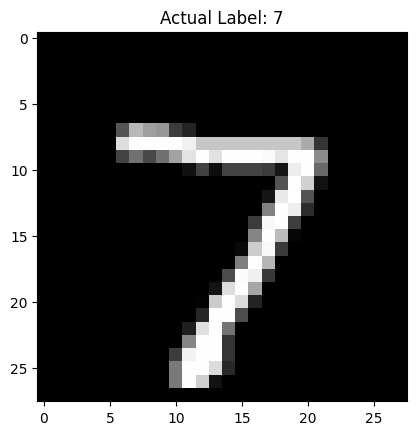

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted Label: 7


In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# Load dataset (automatically downloads MNIST)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display dataset shape
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

# Normalize data (0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convert labels to one-hot encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Build ANN model (Backpropagation happens during training)
model = Sequential()

# Flatten image (28x28 → 784)
model.add(Flatten(input_shape=(28, 28)))

# Hidden layers
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer (10 classes)
model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model (Backpropagation occurs here)
history = model.fit(x_train, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.2)

# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_accuracy)

# Predict sample image
plt.imshow(x_test[0], cmap='gray')
plt.title("Actual Label: " + str(np.argmax(y_test[0])))
plt.show()

prediction = model.predict(x_test[0].reshape(1, 28, 28))
print("Predicted Label:", np.argmax(prediction))